# Visualise Imputed Data

Same heatmaps as `visualise.py`, but built from the imputed CSVs in each dataset's `imputation.output_dir`. Outputs are written to `<image_dir>_imputed/` so the originals aren't overwritten.

In [6]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml
from tqdm import tqdm

from visualise import generate_comparison_df


def plot_site_comparison_heatmap_ordered(df, feature_name, limit_dict, image_dir, column_order):
    """Like visualise.plot_site_comparison_heatmap, but uses an externally
    supplied column order instead of sorting by NaN count."""
    cols = [c for c in column_order if c in df.columns]
    extras = [c for c in df.columns if c not in cols]  # any new sites get appended
    df = df.reindex(columns=cols + extras)
    df_transposed = df.T

    fig, ax = plt.subplots(figsize=(20, len(df.columns) * 0.025))
    vmax = limit_dict.get(feature_name, df.max().max())
    sns.heatmap(
        df_transposed,
        cmap="YlOrRd",
        cbar_kws={"label": feature_name},
        xticklabels=False,
        yticklabels=False,
        ax=ax,
        mask=df_transposed.isna(),
        vmin=0,
        vmax=vmax,
    )

    tick_dates = pd.date_range(start=df.index[0], end=df.index[-1], freq="6MS")
    tick_positions = [df.index.get_loc(ts) for ts in tick_dates if ts in df.index]
    tick_labels = [ts.strftime("%b %Y") for ts in tick_dates if ts in df.index]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)

    plt.title(f"CPCB {feature_name} Across Sites Over Time After Transformation", fontsize=16, pad=20)
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Site", fontsize=12)
    plt.tight_layout()

    safe = feature_name.split(" ")[0]
    plt.savefig(os.path.join(image_dir, f"{safe}.png"), dpi=500, bbox_inches="tight")
    plt.close()


def original_column_order(original_dicts_dir, feature):
    """Reproduce the column ordering used by visualise.plot_site_comparison_heatmap
    on the original (un-imputed) dict: ascending NaN count."""
    safe = feature.split(" ")[0]
    path = os.path.join(original_dicts_dir, f"{safe}_df.csv")
    if not os.path.isfile(path):
        return None
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    return df.isnull().sum().sort_values().index.tolist()

In [7]:
CONFIG_PATH = "config.yaml"
MAKE_DICTS = True  # rebuild per-pollutant comparison DataFrames from imputed CSVs

with open(CONFIG_PATH) as f:
    all_cfg = yaml.safe_load(f)

# Pick which datasets to visualise. By default: every dataset that has both
# a `visualise` and an `imputation` block.
datasets = [k for k, v in all_cfg.items() if isinstance(v, dict) and "visualise" in v and "imputation" in v]
datasets

['cpcb']

In [8]:
def build_imputed_cfg(dataset_key):
    """Merge a dataset's `visualise` + `imputation` config into a vis-style cfg
    pointing at the imputed CSVs, with separate output dirs."""
    vis = all_cfg[dataset_key]["visualise"]
    imp = all_cfg[dataset_key]["imputation"]

    image_dir = vis["output"]["image_dir"].rstrip("/") + "_imputed"
    dicts_dir = vis["output"]["dicts_dir"].rstrip("/") + "_imputed"

    return {
        "folder": imp["output_dir"],
        "date_range": imp.get("date_range", vis["date_range"]),
        "features": imp.get("features", vis["features"]),
        "pollutant_limits": vis["pollutant_limits"],
        "dicts_dir": dicts_dir,
        "image_dir": image_dir,
        "original_dicts_dir": vis["output"]["dicts_dir"],
    }

imputed_cfgs = {k: build_imputed_cfg(k) for k in datasets}
for k, c in imputed_cfgs.items():
    print(f"{k}: folder={c['folder']}\n     -> images={c['image_dir']}, dicts={c['dicts_dir']}")

cpcb: folder=/home/rishi/ML Projects/Air Pollution/CPCB/sites_imputed
     -> images=visualize_cpcb_images_imputed, dicts=/home/rishi/ML Projects/Air Pollution/CPCB/vis_dicts_imputed


In [ ]:
for dataset_key, cfg in imputed_cfgs.items():
    print(f"\n=== {dataset_key} ===")
    if not os.path.isdir(cfg["folder"]):
        print(f"  skipping, imputed folder not found: {cfg['folder']}")
        continue

    os.makedirs(cfg["dicts_dir"], exist_ok=True)
    os.makedirs(cfg["image_dir"], exist_ok=True)

    full_index = pd.date_range(cfg["date_range"]["start"], cfg["date_range"]["end"], freq="h")

    if MAKE_DICTS:
        print("  building per-pollutant comparison DataFrames...")
        for feature in tqdm(cfg["features"]):
            safe = feature.split(" ")[0]
            feature_df = generate_comparison_df(feature, cfg["folder"], full_index)
            feature_df.to_csv(os.path.join(cfg["dicts_dir"], f"{safe}_df.csv"))

    print("  plotting heatmaps...")
    for feature in tqdm(cfg["features"]):
        safe = feature.split(" ")[0]
        feature_df = pd.read_csv(
            os.path.join(cfg["dicts_dir"], f"{safe}_df.csv"),
            index_col=0,
            parse_dates=True,
        )
        col_order = original_column_order(cfg["original_dicts_dir"], feature)
        if col_order is None:
            print(f"    no original dict for {feature}, falling back to NaN-sort order")
            col_order = feature_df.isnull().sum().sort_values().index.tolist()
        plot_site_comparison_heatmap_ordered(
            feature_df, feature, cfg["pollutant_limits"], cfg["image_dir"], col_order
        )

    print(f"  done -> {cfg['image_dir']}/")


=== cpcb comparison ===


 33%|███▎      | 2/6 [00:44<01:29, 22.33s/it]


KeyboardInterrupt: 

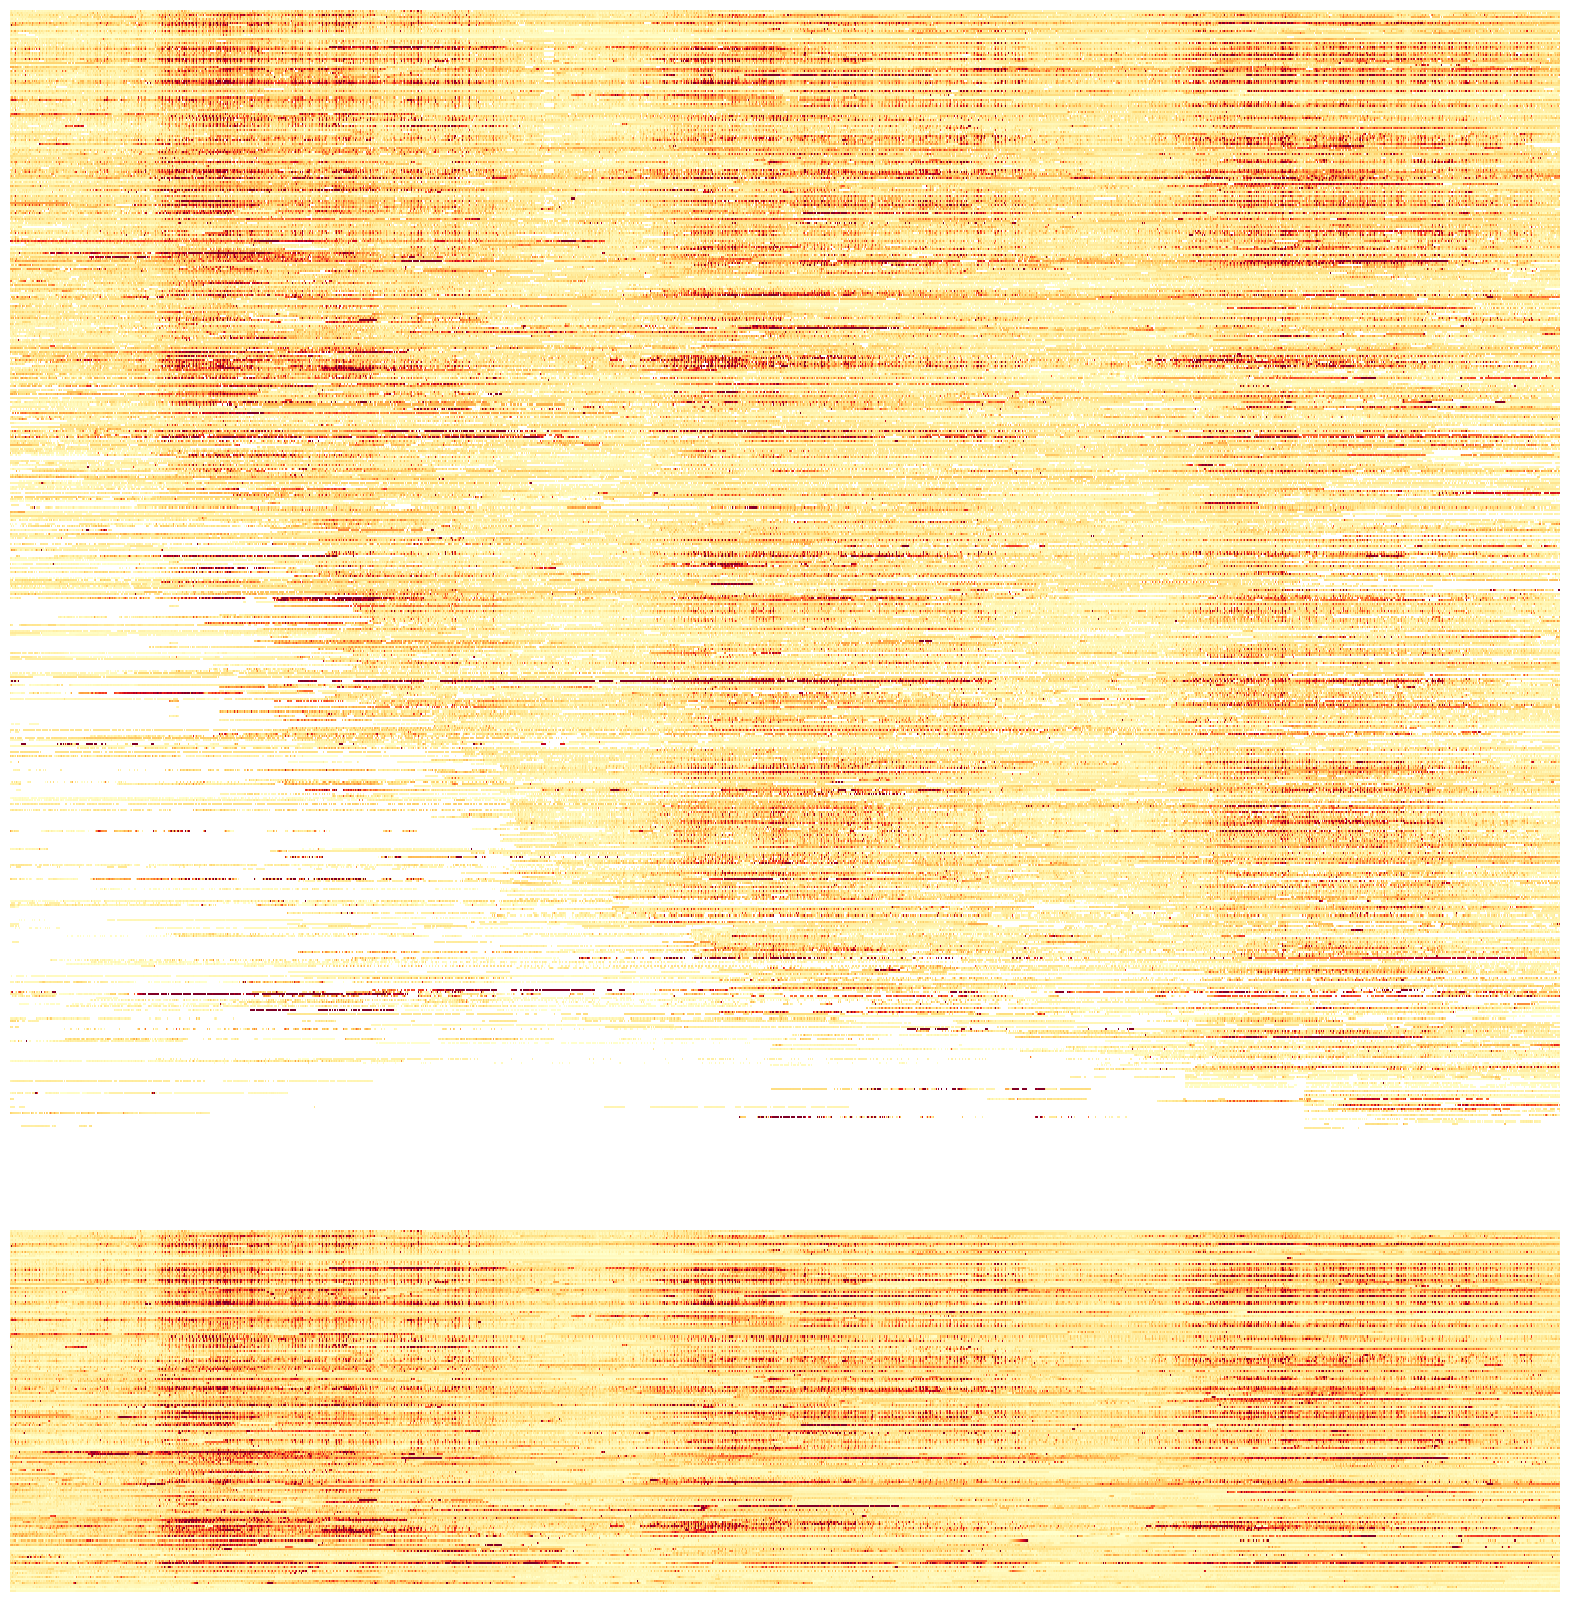

In [10]:

import matplotlib as mpl

COMPARISON_OUTPUT_DIR = "visualize_cpcb_images_comparison"
os.makedirs(COMPARISON_OUTPUT_DIR, exist_ok=True)

for dataset_key, cfg in imputed_cfgs.items():
    raw_dicts_dir = cfg["original_dicts_dir"]
    imp_dicts_dir = cfg["dicts_dir"]
    limit_dict    = cfg["pollutant_limits"]
    features      = cfg["features"]

    print(f"\n=== {dataset_key} comparison ===")

    for feature in tqdm(features):
        safe = feature.split(" ")[0]

        raw_path = os.path.join(raw_dicts_dir, f"{safe}_df.csv")
        imp_path = os.path.join(imp_dicts_dir,  f"{safe}_df.csv")
        if not os.path.isfile(raw_path) or not os.path.isfile(imp_path):
            print(f"  skipping {feature}: missing dict file(s)")
            continue

        raw_df = pd.read_csv(raw_path, index_col=0, parse_dates=True)
        imp_df = pd.read_csv(imp_path, index_col=0, parse_dates=True)

        # Raw: all sites, sorted by NaN count
        raw_col_order = raw_df.isnull().sum().sort_values().index.tolist()
        raw_df = raw_df.reindex(columns=raw_col_order)

        # Imputed: same order as raw, but only columns that actually exist (no NaN padding)
        imp_col_order = [c for c in raw_col_order if c in imp_df.columns]
        extras        = [c for c in imp_df.columns if c not in raw_col_order]
        imp_df        = imp_df.reindex(columns=imp_col_order + extras)

        vmax           = limit_dict.get(feature, max(raw_df.max().max(), imp_df.max().max()))
        raw_height     = len(raw_df.columns) * 0.025
        imp_height     = len(imp_df.columns) * 0.025
        total_height   = raw_height + imp_height + 2

        fig, (ax_raw, ax_imp) = plt.subplots(
            2, 1,
            figsize=(20, total_height),
            gridspec_kw={"height_ratios": [raw_height, imp_height]},
        )
        fig.subplots_adjust(hspace=0.5 / min(raw_height, imp_height))

        tick_dates = pd.date_range(start=raw_df.index[0], end=raw_df.index[-1], freq="6MS")

        for df, ax, show_xaxis in [(raw_df, ax_raw, False), (imp_df, ax_imp, True)]:
            df_T = df.T
            sns.heatmap(
                df_T,
                cmap="YlOrRd",
                cbar=False,
                xticklabels=False,
                yticklabels=False,
                ax=ax,
                mask=df_T.isna(),
                vmin=0,
                vmax=vmax,
            )
            if show_xaxis:
                tick_positions = [df.index.get_loc(ts) for ts in tick_dates if ts in df.index]
                tick_labels    = [ts.strftime("%b %Y")  for ts in tick_dates if ts in df.index]
                ax.set_xticks(tick_positions)
                ax.set_xticklabels(tick_labels, rotation=45, fontsize=28)
                ax.set_xlabel("Year", fontsize=32)
            else:
                ax.set_xticks([])
                ax.set_xlabel("")
            ax.set_ylabel("")

        # Single shared colorbar
        norm = mpl.colors.Normalize(vmin=0, vmax=vmax)
        sm   = mpl.cm.ScalarMappable(cmap="YlOrRd", norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=[ax_raw, ax_imp], label=feature, fraction=0.025, pad=0.02)
        cbar.ax.tick_params(labelsize=28)
        cbar.set_label(feature, fontsize=32)

        # Finalise layout so positions are accurate
        fig.canvas.draw()

        label_x = ax_raw.get_position().x0 - 0.01

        # "Site" label at same x as A/B, centred vertically across both panels
        fig.text(label_x, 0.5, "Site", fontsize=32, va="center", ha="right", rotation=90)

        # A/B labels just outside the left edge, near the top of each panel
        for ax, label in [(ax_raw, "A"), (ax_imp, "B")]:
            pos = ax.get_position()
            fig.text(label_x, pos.y1, label,
                     fontsize=36, fontweight="bold", va="top", ha="right",
                     transform=fig.transFigure)

        # Shift colorbar up
        cbar_pos = cbar.ax.get_position()
        shift    = 0.04
        cbar.ax.set_position([cbar_pos.x0, cbar_pos.y0 + shift,
                               cbar_pos.width, cbar_pos.height - shift])

        plt.savefig(
            os.path.join(COMPARISON_OUTPUT_DIR, f"{safe}_comparison.png"),
            dpi=100,
            bbox_inches="tight",
        )
        plt.close()

    print(f"  done -> {COMPARISON_OUTPUT_DIR}/")
